# Map-aware Person Risk Diffusion Test

이 노트북은 ROS2로 바로 들어가기 전에, **SLAM occupancy map 위에서 사람 감지 위치를 source spot으로 두고 위험도/존재확률이 벽을 넘지 않고 퍼지는지** 테스트하기 위한 실험용이다.

## 목표

```text
가짜 SLAM map 생성
    ↓
source 위치 직접 변경
    ↓
source spot 고정
    ↓
시간이 지날수록 halo 확산
    ↓
halo amplitude는 점점 감소
    ↓
벽/occupied cell 통과 금지
    ↓
최종 risk map 확인
```

## 핵심 모델

고정 source spot:

\[
R_{\text{spot}}(c) = A_{\text{spot}}
\]

확산 halo:

\[
\sigma(t)=\min(\sigma_0+v_{\text{spread}}t,\sigma_{\max})
\]

\[
A(t)=A_0 e^{-\lambda t}
\]

\[
R_{\text{halo}}(c,t)=A(t)\exp\left(-\frac{d_{\text{free}}(c,s)^2}{2\sigma(t)^2}\right)
\]

최종 맵:

\[
R(c,t)=\max(R_{\text{spot}}(c),R_{\text{halo}}(c,t))
\]

여기서 \(d_{\text{free}}\)는 벽을 통과하지 않고 free cell만 지나가는 거리다.

## 1. 설치

필요한 패키지:

```zsh
pip install numpy matplotlib pandas ipywidgets
```

Jupyter에서 widget이 안 보이면:

```zsh
pip install ipywidgets
jupyter nbextension enable --py widgetsnbextension
```

JupyterLab이면 보통 `ipywidgets`만 설치하면 된다.

In [49]:
# 필요할 때만 실행
# !pip install -U numpy matplotlib pandas ipywidgets

## 2. Import

In [50]:
import math
import heapq
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except Exception as e:
    HAS_WIDGETS = False
    print("ipywidgets unavailable:", e)

print("numpy:", np.__version__)

numpy: 2.4.6


## 3. 가짜 SLAM OccupancyGrid 만들기

값 의미는 ROS `nav_msgs/OccupancyGrid`와 맞춘다.

```text
-1  unknown
0   free
100 occupied/wall
```

맵 구조:

```text
- 외곽 벽
- 내부 방 3개
- 복도
- 문 통로 몇 개
- 일부 unknown 영역
```

이걸로 source가 방 안에 있을 때 위험도가 벽 너머 방으로 넘어가지 않는지 확인한다.

In [51]:
@dataclass
class GridSpec:
    width_m: float = 12.0
    height_m: float = 10.0
    resolution: float = 0.05
    origin_x: float = -6.0
    origin_y: float = -5.0

    @property
    def width_cells(self) -> int:
        return int(round(self.width_m / self.resolution))

    @property
    def height_cells(self) -> int:
        return int(round(self.height_m / self.resolution))


grid = GridSpec()


def world_to_grid(x: float, y: float, spec: GridSpec = grid) -> Optional[Tuple[int, int]]:
    max_x = spec.origin_x + spec.width_m
    max_y = spec.origin_y + spec.height_m
    eps = 1e-9

    # 맵 바깥이면 None. 경계선(최대값)은 마지막 셀로 포함한다.
    if x < spec.origin_x - eps or x > max_x + eps or y < spec.origin_y - eps or y > max_y + eps:
        return None

    if x >= max_x:
        gx = spec.width_cells - 1
    else:
        gx = int(math.floor((x - spec.origin_x) / spec.resolution))

    if y >= max_y:
        gy = spec.height_cells - 1
    else:
        gy = int(math.floor((y - spec.origin_y) / spec.resolution))

    if gx < 0 or gx >= spec.width_cells or gy < 0 or gy >= spec.height_cells:
        return None
    return gx, gy


def grid_to_world(gx: int, gy: int, spec: GridSpec = grid) -> Tuple[float, float]:
    x = spec.origin_x + (gx + 0.5) * spec.resolution
    y = spec.origin_y + (gy + 0.5) * spec.resolution
    return x, y


def rect_to_grid(x0, y0, x1, y1, spec: GridSpec = grid):
    g0 = world_to_grid(x0, y0, spec)
    g1 = world_to_grid(x1, y1, spec)
    if g0 is None or g1 is None:
        raise ValueError("rectangle point outside map")
    gx0, gy0 = g0
    gx1, gy1 = g1
    return min(gx0, gx1), min(gy0, gy1), max(gx0, gx1), max(gy0, gy1)


def draw_wall_rect(occ, x0, y0, x1, y1, value=100):
    gx0, gy0, gx1, gy1 = rect_to_grid(x0, y0, x1, y1)
    occ[gy0:gy1 + 1, gx0:gx1 + 1] = value


def draw_free_rect(occ, x0, y0, x1, y1):
    gx0, gy0, gx1, gy1 = rect_to_grid(x0, y0, x1, y1)
    occ[gy0:gy1 + 1, gx0:gx1 + 1] = 0


def make_demo_occupancy_map(spec: GridSpec = grid) -> np.ndarray:
    h, w = spec.height_cells, spec.width_cells

    # 기본은 free
    occ = np.zeros((h, w), dtype=np.int16)

    # 외곽 벽
    wall = 0.15
    draw_wall_rect(occ, spec.origin_x, spec.origin_y, spec.origin_x + spec.width_m, spec.origin_y + wall)
    draw_wall_rect(occ, spec.origin_x, spec.origin_y + spec.height_m - wall, spec.origin_x + spec.width_m, spec.origin_y + spec.height_m)
    draw_wall_rect(occ, spec.origin_x, spec.origin_y, spec.origin_x + wall, spec.origin_y + spec.height_m)
    draw_wall_rect(occ, spec.origin_x + spec.width_m - wall, spec.origin_y, spec.origin_x + spec.width_m, spec.origin_y + spec.height_m)

    # 내부 벽: 세로 벽 2개
    draw_wall_rect(occ, -2.2, -4.8, -2.0, 4.8)
    draw_wall_rect(occ,  2.0, -4.8,  2.2, 4.8)

    # 내부 벽: 가로 벽
    draw_wall_rect(occ, -5.8, 0.8, 5.8, 1.0)

    # 문 열기: 세로 벽의 문
    draw_free_rect(occ, -2.25, -0.6, -1.95, 0.4)
    draw_free_rect(occ,  1.95, -2.1,  2.25, -1.1)
    draw_free_rect(occ,  1.95,  2.1,  2.25,  3.1)

    # 문 열기: 가로 벽의 문
    draw_free_rect(occ, -4.4, 0.75, -3.3, 1.05)
    draw_free_rect(occ,  3.3, 0.75,  4.4, 1.05)

    # 장애물 몇 개
    draw_wall_rect(occ, -4.8, -3.6, -4.1, -2.9)
    draw_wall_rect(occ,  3.8, -3.8,  4.6, -3.0)
    draw_wall_rect(occ, -0.5,  2.2,  0.4,  2.9)

    # unknown 영역 일부
    draw_wall_rect(occ, 4.8, 1.6, 5.7, 4.5, value=-1)
    draw_wall_rect(occ, -5.5, 2.2, -4.8, 4.3, value=-1)

    return occ


occ_grid = make_demo_occupancy_map(grid)

print("map shape:", occ_grid.shape)
print("free:", np.sum(occ_grid == 0), "occupied:", np.sum(occ_grid >= 65), "unknown:", np.sum(occ_grid == -1))

map shape: (200, 240)
free: 39350 occupied: 6925 unknown: 1725


## 4. Map 시각화 함수

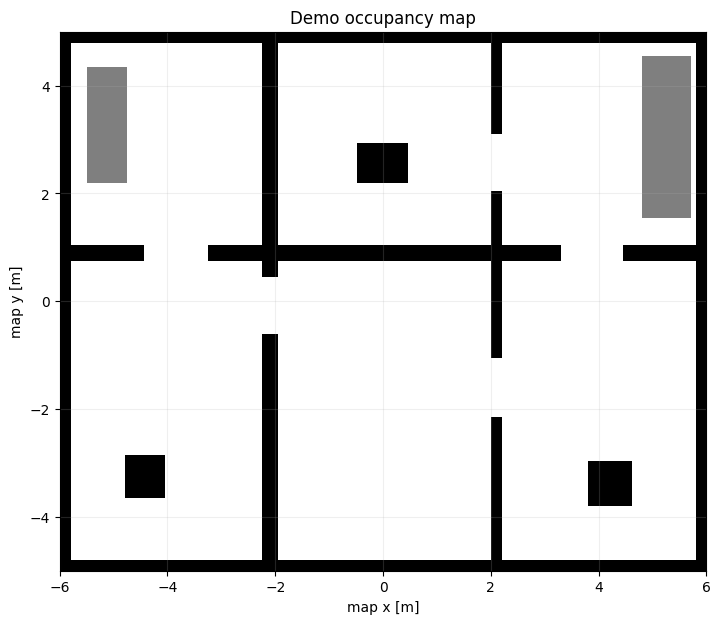

In [52]:
def plot_occupancy_map(occ: np.ndarray, spec: GridSpec = grid, ax=None, title="Demo occupancy map"):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))

    # 표시용: unknown=-1, free=0, occupied=1
    vis = np.zeros_like(occ, dtype=float)
    vis[occ == -1] = 0.5
    vis[occ >= 65] = 1.0
    vis[(occ >= 0) & (occ < 65)] = 0.0

    extent = [
        spec.origin_x,
        spec.origin_x + spec.width_m,
        spec.origin_y,
        spec.origin_y + spec.height_m,
    ]

    ax.imshow(
        vis,
        origin="lower",
        extent=extent,
        cmap="gray_r",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )
    ax.set_xlabel("map x [m]")
    ax.set_ylabel("map y [m]")
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    ax.set_aspect("equal")
    return ax


plot_occupancy_map(occ_grid)
plt.show()

## 5. Traversability / nearest free / geodesic distance

확산은 occupancy map의 free-space를 따라 진행한다.

- occupied wall: 통과 금지
- unknown: 기본 통과 금지
- 8-neighbor Dijkstra 사용
- diagonal 이동 비용은 \(\sqrt{2}\Delta r\)

In [53]:
def is_traversable(
    occ_value: int,
    free_threshold: int = 30,
    occupied_threshold: int = 65,
    allow_unknown: bool = False,
) -> bool:
    if occ_value == -1:
        return allow_unknown
    if occ_value >= occupied_threshold:
        return False
    return occ_value <= free_threshold


def nearest_traversable_cell(
    occ: np.ndarray,
    gx: int,
    gy: int,
    max_radius_cells: int = 20,
    allow_unknown: bool = False,
    free_threshold: int = 30,
    occupied_threshold: int = 65,
) -> Optional[Tuple[int, int]]:
    h, w = occ.shape

    if 0 <= gx < w and 0 <= gy < h:
        if is_traversable(int(occ[gy, gx]), free_threshold, occupied_threshold, allow_unknown):
            return gx, gy

    best = None
    best_d2 = None

    for r in range(1, max_radius_cells + 1):
        x0 = max(0, gx - r)
        x1 = min(w - 1, gx + r)
        y0 = max(0, gy - r)
        y1 = min(h - 1, gy + r)

        # ring만 검사
        candidates = []
        for x in range(x0, x1 + 1):
            candidates.append((x, y0))
            candidates.append((x, y1))
        for y in range(y0 + 1, y1):
            candidates.append((x0, y))
            candidates.append((x1, y))

        for x, y in candidates:
            if not is_traversable(int(occ[y, x]), free_threshold, occupied_threshold, allow_unknown):
                continue
            d2 = (x - gx) ** 2 + (y - gy) ** 2
            if best_d2 is None or d2 < best_d2:
                best = (x, y)
                best_d2 = d2

        if best is not None:
            return best

    return None


def dijkstra_free_space_distances(
    occ: np.ndarray,
    start_gx: int,
    start_gy: int,
    max_radius_m: float,
    resolution: float,
    allow_unknown: bool = False,
    free_threshold: int = 30,
    occupied_threshold: int = 65,
    use_8_neighbor: bool = True,
) -> np.ndarray:
    h, w = occ.shape
    inf = np.inf
    dist = np.full((h, w), inf, dtype=np.float32)

    if not (0 <= start_gx < w and 0 <= start_gy < h):
        return dist

    if not is_traversable(int(occ[start_gy, start_gx]), free_threshold, occupied_threshold, allow_unknown):
        return dist

    if use_8_neighbor:
        neighbors = [
            (-1, -1, math.sqrt(2.0) * resolution),
            ( 0, -1, 1.0 * resolution),
            ( 1, -1, math.sqrt(2.0) * resolution),
            (-1,  0, 1.0 * resolution),
            ( 1,  0, 1.0 * resolution),
            (-1,  1, math.sqrt(2.0) * resolution),
            ( 0,  1, 1.0 * resolution),
            ( 1,  1, math.sqrt(2.0) * resolution),
        ]
    else:
        neighbors = [
            (0, -1, resolution),
            (-1, 0, resolution),
            (1, 0, resolution),
            (0, 1, resolution),
        ]

    pq = []
    dist[start_gy, start_gx] = 0.0
    heapq.heappush(pq, (0.0, start_gx, start_gy))

    while pq:
        d, gx, gy = heapq.heappop(pq)
        if d != dist[gy, gx]:
            continue

        if d > max_radius_m:
            continue

        for dx, dy, cost in neighbors:
            nx = gx + dx
            ny = gy + dy

            if nx < 0 or nx >= w or ny < 0 or ny >= h:
                continue

            if not is_traversable(int(occ[ny, nx]), free_threshold, occupied_threshold, allow_unknown):
                continue

            nd = d + cost
            if nd > max_radius_m:
                continue

            if nd < dist[ny, nx]:
                dist[ny, nx] = nd
                heapq.heappush(pq, (nd, nx, ny))

    return dist

## 6. Simplified Bayesian Person Belief Map

이 섹션은 사람 확률맵을 베이지안 방식으로 갱신한다.

- `source_memory_map`: 과거 관측 evidence 메모리 (clear 전까지 유지)
- `current_person_belief_map`: 현재 사람이 있을 확률 (매 스텝 갱신)

매 스텝 처리 순서:
1. motion prediction (free-space 확산)
2. visibility mask 계산
3. detection 있으면 확률 증가
4. detection 없으면 visible 영역 확률 감소
5. wall/unknown 정리 후 risk 융합

In [54]:
@dataclass
class BearingEvidence:
    id: int
    robot_x: float
    robot_y: float
    robot_yaw: float
    bearing_rad: float
    bearing_sigma_rad: float
    min_range_m: float
    max_range_m: float
    confidence: float
    stamp: float = 0.0
    spread_speed_mps: float = 0.20
    halo_decay_rate: float = 0.04
    cleared: bool = False


def wrap_angle(rad: float) -> float:
    return math.atan2(math.sin(rad), math.cos(rad))


def angle_diff(a: float, b: float) -> float:
    return wrap_angle(a - b)


def _range_weight_piecewise(distance_m: float) -> float:
    if distance_m < 0.5:
        return 0.3
    if distance_m < 3.0:
        return 1.0
    if distance_m < 5.0:
        return 0.5
    return 0.1


def _raycast_points(
    occ: np.ndarray,
    start_x: float,
    start_y: float,
    theta: float,
    min_range_m: float,
    max_range_m: float,
    spec: GridSpec,
    allow_unknown: bool,
    free_threshold: int,
    occupied_threshold: int,
) -> List[Tuple[int, int, float, float]]:
    points: List[Tuple[int, int, float, float]] = []
    step_r = max(spec.resolution, 0.03)
    r = max(0.0, min_range_m)
    visited = set()

    while r <= max_range_m + 1e-9:
        x = start_x + r * math.cos(theta)
        y = start_y + r * math.sin(theta)
        g = world_to_grid(x, y, spec)
        if g is None:
            break

        gx, gy = g
        if (gx, gy) in visited:
            r += step_r
            continue
        visited.add((gx, gy))

        occ_v = int(occ[gy, gx])
        if occ_v == -1 and not allow_unknown:
            break
        if occ_v >= occupied_threshold:
            break
        if occ_v > free_threshold:
            r += step_r
            continue

        theta_cell = math.atan2(y - start_y, x - start_x)
        points.append((gx, gy, r, theta_cell))
        r += step_r

    return points


def create_bearing_detection_source_map(
    occ: np.ndarray,
    evidence: BearingEvidence,
    spec: GridSpec = grid,
    angular_width_sigma: float = 3.0,
    range_sigma_m: float = 1.0,
    range_decay: float = 0.15,
    use_bbox_range_prior: bool = False,
    range_prior_mean_m: Optional[float] = None,
    allow_unknown: bool = False,
    free_threshold: int = 30,
    occupied_threshold: int = 65,
) -> Dict:
    h, w = occ.shape
    source_map = np.zeros((h, w), dtype=np.float32)

    if world_to_grid(evidence.robot_x, evidence.robot_y, spec) is None:
        return {
            "ok": False,
            "reason": "robot_outside_map",
            "source_map": source_map,
            "theta_map": None,
            "candidate_count": 0,
        }

    theta0 = wrap_angle(evidence.robot_yaw + evidence.bearing_rad)
    sigma_theta = max(evidence.bearing_sigma_rad, math.radians(1.0))
    half_width = angular_width_sigma * sigma_theta

    n_angles = max(21, int(round((2.0 * half_width) / math.radians(0.5))) + 1)
    angle_samples = np.linspace(theta0 - half_width, theta0 + half_width, n_angles)

    candidate_count = 0
    for theta in angle_samples:
        dth = angle_diff(theta, theta0)
        angle_w = math.exp(-0.5 * (dth / sigma_theta) ** 2)

        ray_points = _raycast_points(
            occ=occ,
            start_x=evidence.robot_x,
            start_y=evidence.robot_y,
            theta=theta,
            min_range_m=evidence.min_range_m,
            max_range_m=evidence.max_range_m,
            spec=spec,
            allow_unknown=allow_unknown,
            free_threshold=free_threshold,
            occupied_threshold=occupied_threshold,
        )

        for gx, gy, r, _ in ray_points:
            range_w = math.exp(-range_decay * r)
            if use_bbox_range_prior and range_prior_mean_m is not None:
                sigma_r = max(range_sigma_m, 0.2)
                range_w *= math.exp(-0.5 * ((r - range_prior_mean_m) / sigma_r) ** 2)

            value = float(evidence.confidence * angle_w * range_w)
            if value > source_map[gy, gx]:
                if source_map[gy, gx] <= 1e-9:
                    candidate_count += 1
                source_map[gy, gx] = value

    return {
        "ok": True,
        "reason": "ok",
        "source_map": source_map,
        "theta_map": theta0,
        "candidate_count": candidate_count,
    }


def diffuse_belief_through_free_space(
    belief_prev: np.ndarray,
    occ: np.ndarray,
    spec: GridSpec = grid,
    motion_sigma_m_per_step: float = 0.15,
    diffusion_radius_sigma: float = 3.0,
    belief_decay: float = 0.995,
    top_k_seeds: int = 120,
    allow_unknown: bool = False,
    free_threshold: int = 30,
    occupied_threshold: int = 65,
) -> np.ndarray:
    h, w = occ.shape
    belief_prev = np.clip(belief_prev, 0.0, 1.0).astype(np.float32)
    belief_pred = (belief_prev * belief_decay).astype(np.float32)

    ys, xs = np.where(belief_prev > 1e-4)
    if len(xs) == 0:
        return belief_pred

    vals = belief_prev[ys, xs]
    order = np.argsort(vals)[::-1][:top_k_seeds]

    radius_m = max(spec.resolution, diffusion_radius_sigma * motion_sigma_m_per_step)

    for idx in order:
        sgx = int(xs[idx])
        sgy = int(ys[idx])
        seed_value = float(vals[idx])

        dist = dijkstra_free_space_distances(
            occ=occ,
            start_gx=sgx,
            start_gy=sgy,
            max_radius_m=radius_m,
            resolution=spec.resolution,
            allow_unknown=allow_unknown,
            free_threshold=free_threshold,
            occupied_threshold=occupied_threshold,
            use_8_neighbor=True,
        )

        mask = np.isfinite(dist) & (dist <= radius_m)
        if not np.any(mask):
            continue

        local = np.zeros_like(belief_pred)
        sigma = max(motion_sigma_m_per_step, 1e-6)
        local[mask] = seed_value * np.exp(-0.5 * (dist[mask] / sigma) ** 2)
        belief_pred = np.maximum(belief_pred, local.astype(np.float32))

    return np.clip(belief_pred, 0.0, 1.0)


def compute_visibility_and_detection_probability(
    occ: np.ndarray,
    robot_x: float,
    robot_y: float,
    robot_yaw: float,
    camera_hfov_deg: float,
    min_range_m: float,
    max_range_m: float,
    spec: GridSpec = grid,
    p_detect_max: float = 0.75,
    angle_sigma_deg: float = 20.0,
    allow_unknown: bool = False,
    free_threshold: int = 30,
    occupied_threshold: int = 65,
    ray_step_deg: float = 0.5,
) -> Tuple[np.ndarray, np.ndarray]:
    h, w = occ.shape
    visible_mask = np.zeros((h, w), dtype=bool)
    p_detect = np.zeros((h, w), dtype=np.float32)

    if world_to_grid(robot_x, robot_y, spec) is None:
        return visible_mask, p_detect

    hfov_rad = math.radians(camera_hfov_deg)
    half = 0.5 * hfov_rad
    angle_sigma = max(math.radians(angle_sigma_deg), math.radians(2.0))

    n_angles = max(21, int(round((2.0 * half) / math.radians(ray_step_deg))) + 1)
    angle_samples = np.linspace(robot_yaw - half, robot_yaw + half, n_angles)

    for theta in angle_samples:
        ray_points = _raycast_points(
            occ=occ,
            start_x=robot_x,
            start_y=robot_y,
            theta=theta,
            min_range_m=min_range_m,
            max_range_m=max_range_m,
            spec=spec,
            allow_unknown=allow_unknown,
            free_threshold=free_threshold,
            occupied_threshold=occupied_threshold,
        )

        for gx, gy, r, theta_cell in ray_points:
            visible_mask[gy, gx] = True

            dtheta = abs(angle_diff(theta_cell, robot_yaw))
            angle_w = math.exp(-0.5 * (dtheta / angle_sigma) ** 2)
            range_w = _range_weight_piecewise(r)
            p = float(np.clip(p_detect_max * angle_w * range_w, 0.0, 1.0))
            if p > p_detect[gy, gx]:
                p_detect[gy, gx] = p

    return visible_mask, p_detect


def bayesian_person_belief_step(
    occ: np.ndarray,
    belief_prev: np.ndarray,
    source_memory_prev: np.ndarray,
    robot_x: float,
    robot_y: float,
    robot_yaw: float,
    detection_evidence: Optional[BearingEvidence],
    spec: GridSpec = grid,
    camera_hfov_deg: float = 62.0,
    vis_min_range_m: float = 0.5,
    vis_max_range_m: float = 5.0,
    clear_strength: float = 0.12,
    p_detect_max: float = 0.75,
    motion_sigma_m_per_step: float = 0.15,
    belief_decay: float = 0.995,
    detection_gate: float = 0.1,
    bearing_sigma_deg_default: float = 6.0,
    range_sigma_m: float = 1.0,
    use_bbox_range_prior: bool = False,
    range_prior_mean_m: Optional[float] = None,
    source_memory_weight: float = 0.7,
    current_belief_weight: float = 1.0,
    allow_unknown: bool = False,
    free_threshold: int = 30,
    occupied_threshold: int = 65,
) -> Dict:
    h, w = occ.shape
    belief_prev = np.clip(belief_prev, 0.0, 1.0).astype(np.float32)
    source_memory_prev = np.clip(source_memory_prev, 0.0, 1.0).astype(np.float32)

    belief_pred = diffuse_belief_through_free_space(
        belief_prev=belief_prev,
        occ=occ,
        spec=spec,
        motion_sigma_m_per_step=motion_sigma_m_per_step,
        belief_decay=belief_decay,
        allow_unknown=allow_unknown,
        free_threshold=free_threshold,
        occupied_threshold=occupied_threshold,
    )

    visible_mask, p_detect = compute_visibility_and_detection_probability(
        occ=occ,
        robot_x=robot_x,
        robot_y=robot_y,
        robot_yaw=robot_yaw,
        camera_hfov_deg=camera_hfov_deg,
        min_range_m=vis_min_range_m,
        max_range_m=vis_max_range_m,
        spec=spec,
        p_detect_max=p_detect_max,
        allow_unknown=allow_unknown,
        free_threshold=free_threshold,
        occupied_threshold=occupied_threshold,
    )

    belief = belief_pred.copy()
    source_memory_map = source_memory_prev.copy()
    detection_source = np.zeros((h, w), dtype=np.float32)
    theta_map = None
    detection_used = False

    if detection_evidence is not None and detection_evidence.confidence > 1e-6:
        if detection_evidence.bearing_sigma_rad <= 0.0:
            detection_evidence = BearingEvidence(
                id=detection_evidence.id,
                robot_x=detection_evidence.robot_x,
                robot_y=detection_evidence.robot_y,
                robot_yaw=detection_evidence.robot_yaw,
                bearing_rad=detection_evidence.bearing_rad,
                bearing_sigma_rad=math.radians(bearing_sigma_deg_default),
                min_range_m=detection_evidence.min_range_m,
                max_range_m=detection_evidence.max_range_m,
                confidence=detection_evidence.confidence,
                stamp=detection_evidence.stamp,
                spread_speed_mps=detection_evidence.spread_speed_mps,
                halo_decay_rate=detection_evidence.halo_decay_rate,
                cleared=detection_evidence.cleared,
            )

        det_result = create_bearing_detection_source_map(
            occ=occ,
            evidence=detection_evidence,
            spec=spec,
            angular_width_sigma=3.0,
            range_sigma_m=range_sigma_m,
            range_decay=0.15,
            use_bbox_range_prior=use_bbox_range_prior,
            range_prior_mean_m=range_prior_mean_m,
            allow_unknown=allow_unknown,
            free_threshold=free_threshold,
            occupied_threshold=occupied_threshold,
        )

        if det_result["ok"]:
            detection_source = det_result["source_map"]
            theta_map = det_result["theta_map"]
            detection_used = True

            # positive update
            belief = 1.0 - (1.0 - belief) * (1.0 - detection_source)
            source_memory_map = np.maximum(source_memory_map, detection_source)

    # negative update only in visible area not explained by detection
    non_detected_visible = visible_mask & (detection_source < detection_gate)
    belief[non_detected_visible] *= (1.0 - clear_strength * p_detect[non_detected_visible])

    # map constraints
    belief[occ >= occupied_threshold] = 0.0
    source_memory_map[occ >= occupied_threshold] = 0.0
    if not allow_unknown:
        belief[occ == -1] = 0.0
        source_memory_map[occ == -1] = 0.0

    belief = np.clip(belief, 0.0, 1.0).astype(np.float32)
    source_memory_map = np.clip(source_memory_map, 0.0, 1.0).astype(np.float32)

    risk_map = np.maximum(
        source_memory_weight * source_memory_map,
        current_belief_weight * belief,
    ).astype(np.float32)

    return {
        "ok": True,
        "reason": "ok",
        "detection_used": detection_used,
        "theta_map": theta_map,
        "belief_pred_map": belief_pred,
        "detection_source_map": detection_source,
        "source_memory_map": source_memory_map,
        "current_person_belief_map": belief,
        "visibility_map": visible_mask.astype(np.float32),
        "p_detect_map": p_detect,
        "risk_map": risk_map,
    }

## 7. Bayesian belief 시각화 + 기본 시나리오

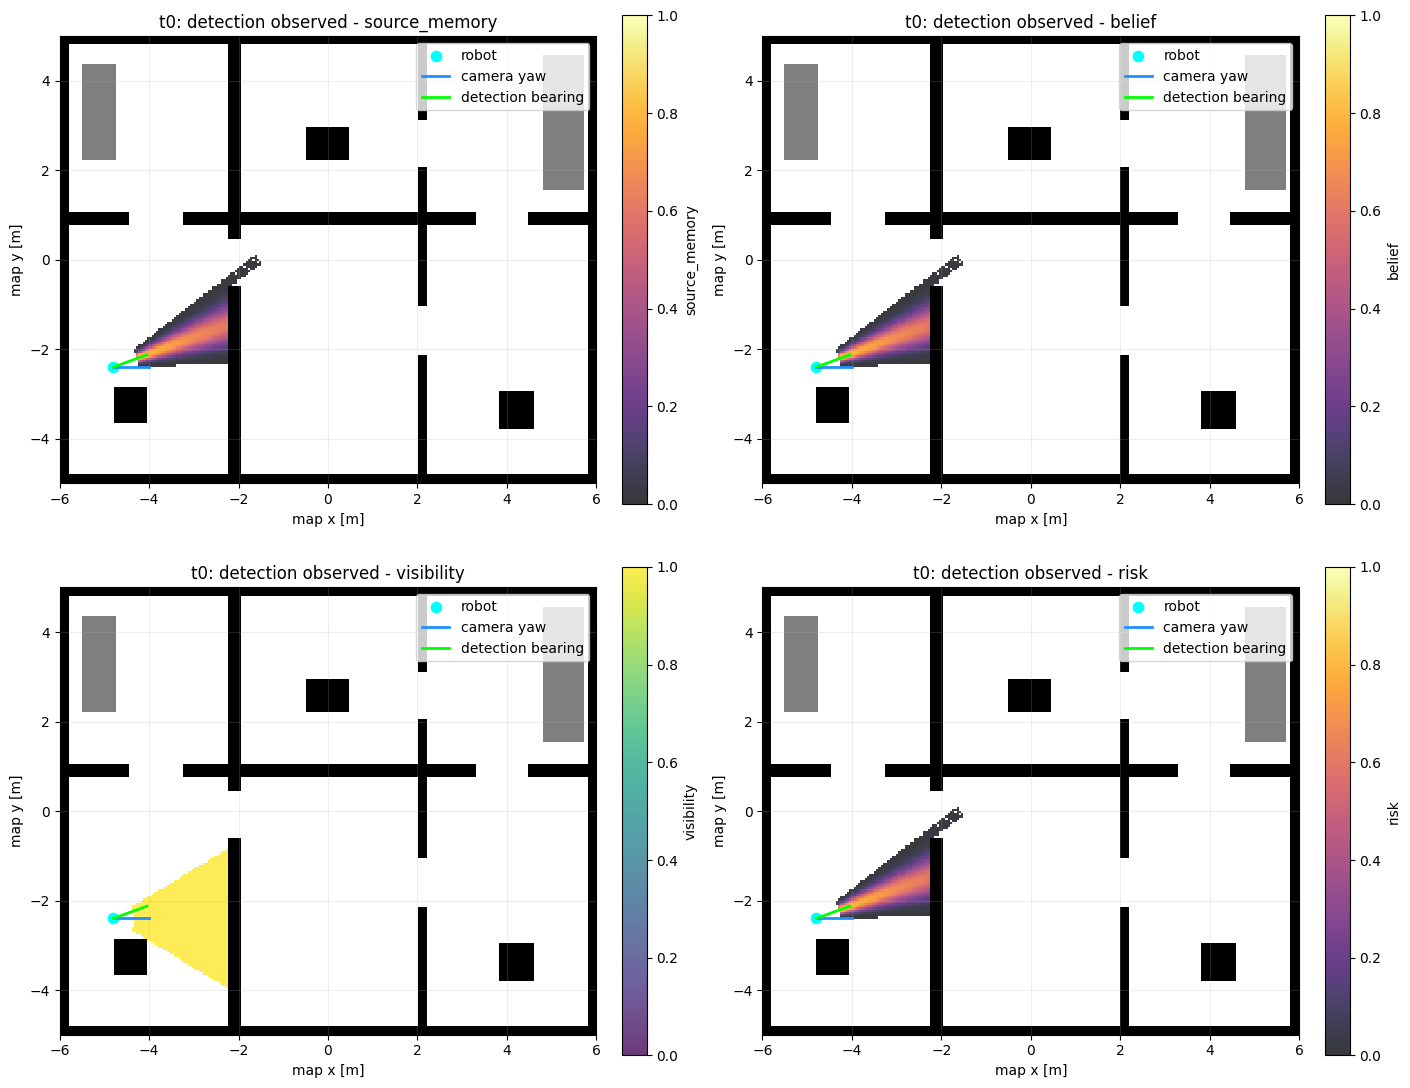

In [55]:
def diffuse_belief_through_free_space(
    belief_prev: np.ndarray,
    occ: np.ndarray,
    spec: GridSpec = grid,
    motion_sigma_m_per_step: float = 0.15,
    diffusion_radius_sigma: float = 3.0,
    belief_decay: float = 0.995,
    top_k_seeds: int = 120,
    allow_unknown: bool = False,
    free_threshold: int = 30,
    occupied_threshold: int = 65,
) -> np.ndarray:
    belief_prev = np.clip(belief_prev, 0.0, 1.0).astype(np.float32)
    h, w = belief_prev.shape
    belief_pred = np.zeros((h, w), dtype=np.float32)

    ys, xs = np.where(belief_prev > 1e-5)
    if len(xs) == 0:
        return belief_pred

    vals = belief_prev[ys, xs]
    order = np.argsort(vals)[::-1][:top_k_seeds]

    radius_m = max(spec.resolution, diffusion_radius_sigma * motion_sigma_m_per_step)
    sigma = max(motion_sigma_m_per_step, 1e-6)

    for idx in order:
        sgx = int(xs[idx])
        sgy = int(ys[idx])
        seed_mass = float(vals[idx]) * belief_decay

        dist = dijkstra_free_space_distances(
            occ=occ,
            start_gx=sgx,
            start_gy=sgy,
            max_radius_m=radius_m,
            resolution=spec.resolution,
            allow_unknown=allow_unknown,
            free_threshold=free_threshold,
            occupied_threshold=occupied_threshold,
            use_8_neighbor=True,
        )

        mask = np.isfinite(dist) & (dist <= radius_m)
        if not np.any(mask):
            continue

        weights = np.zeros_like(belief_pred)
        weights[mask] = np.exp(-0.5 * (dist[mask] / sigma) ** 2)
        wsum = float(np.sum(weights))
        if wsum <= 1e-12:
            continue

        belief_pred += (seed_mass / wsum) * weights

    belief_pred[occ >= occupied_threshold] = 0.0
    if not allow_unknown:
        belief_pred[occ == -1] = 0.0

    return np.clip(belief_pred, 0.0, 1.0).astype(np.float32)


def plot_bayesian_maps(
    occ: np.ndarray,
    result: Dict,
    robot_x: float,
    robot_y: float,
    robot_yaw: float,
    theta_map: Optional[float] = None,
    spec: GridSpec = grid,
    title: str = "Bayesian person belief update",
    show_layers: str = "all",  # "belief", "source_memory", "visibility", "risk", "all"
):
    extent = [
        spec.origin_x,
        spec.origin_x + spec.width_m,
        spec.origin_y,
        spec.origin_y + spec.height_m,
    ]

    layers = {
        "belief": result["current_person_belief_map"],
        "source_memory": result["source_memory_map"],
        "visibility": result["visibility_map"],
        "risk": result["risk_map"],
    }

    if show_layers == "all":
        fig, axes = plt.subplots(2, 2, figsize=(14, 11), constrained_layout=True)
        axes = axes.ravel()
        names = ["source_memory", "belief", "visibility", "risk"]
    else:
        fig, ax = plt.subplots(1, 1, figsize=(8, 7), constrained_layout=True)
        axes = [ax]
        names = [show_layers]

    for ax, name in zip(axes, names):
        plot_occupancy_map(occ, spec=spec, ax=ax, title=f"{title} - {name}")
        data = layers[name]
        masked = np.ma.masked_where(data <= 1e-6, data)
        cmap = "viridis" if name == "visibility" else "inferno"
        im = ax.imshow(
            masked,
            origin="lower",
            extent=extent,
            cmap=cmap,
            vmin=0.0,
            vmax=1.0,
            alpha=0.78,
            interpolation="nearest",
        )

        ax.scatter([robot_x], [robot_y], c="cyan", marker="o", s=55, label="robot")
        ax.plot(
            [robot_x, robot_x + 0.8 * math.cos(robot_yaw)],
            [robot_y, robot_y + 0.8 * math.sin(robot_yaw)],
            c="dodgerblue", linewidth=2.0, label="camera yaw"
        )

        if theta_map is not None:
            ax.plot(
                [robot_x, robot_x + 0.8 * math.cos(theta_map)],
                [robot_y, robot_y + 0.8 * math.sin(theta_map)],
                c="lime", linewidth=2.0, label="detection bearing"
            )

        ax.legend(loc="upper right")
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cb.set_label(name)

    plt.show()


# 기본 시나리오: t0 detection, t1 no detection
belief0 = np.zeros_like(occ_grid, dtype=np.float32)
source_memory0 = np.zeros_like(occ_grid, dtype=np.float32)

ev0 = BearingEvidence(
    id=1,
    robot_x=-4.8,
    robot_y=-2.4,
    robot_yaw=math.radians(0.0),
    bearing_rad=math.radians(20.0),
    bearing_sigma_rad=math.radians(6.0),
    min_range_m=0.6,
    max_range_m=4.0,
    confidence=0.9,
)

res_t0 = bayesian_person_belief_step(
    occ=occ_grid,
    belief_prev=belief0,
    source_memory_prev=source_memory0,
    robot_x=ev0.robot_x,
    robot_y=ev0.robot_y,
    robot_yaw=ev0.robot_yaw,
    detection_evidence=ev0,
    camera_hfov_deg=62.0,
    vis_min_range_m=0.5,
    vis_max_range_m=5.0,
    clear_strength=0.12,
    motion_sigma_m_per_step=0.15,
    belief_decay=0.995,
    source_memory_weight=0.7,
    current_belief_weight=1.0,
    allow_unknown=False,
)

plot_bayesian_maps(
    occ=occ_grid,
    result=res_t0,
    robot_x=ev0.robot_x,
    robot_y=ev0.robot_y,
    robot_yaw=ev0.robot_yaw,
    theta_map=res_t0["theta_map"],
    title="t0: detection observed",
    show_layers="all",
)

## 8. 슬라이더로 Bayesian 업데이트 실험

- `detected`: 사람 detection 존재 여부
- detection 있으면 bearing source로 positive update
- detection 없으면 visible free-space만 negative update
- `source_memory_map`은 detection evidence를 누적 유지

권장: `allow_unknown=False`, `clear_strength=0.12`, `p_detect_max=0.75`.

In [56]:
if HAS_WIDGETS:
    robot_x_slider = widgets.FloatSlider(
        value=-4.8, min=grid.origin_x + 0.3, max=grid.origin_x + grid.width_m - 0.3,
        step=0.05, description="robot_x", continuous_update=False
    )
    robot_y_slider = widgets.FloatSlider(
        value=-2.4, min=grid.origin_y + 0.3, max=grid.origin_y + grid.height_m - 0.3,
        step=0.05, description="robot_y", continuous_update=False
    )
    robot_yaw_slider = widgets.FloatSlider(
        value=0.0, min=-180.0, max=180.0, step=1.0,
        description="yaw_deg", continuous_update=False
    )
    detected_checkbox = widgets.Checkbox(value=True, description="detected")
    bearing_slider = widgets.FloatSlider(
        value=20.0, min=-60.0, max=60.0, step=1.0,
        description="bearing", continuous_update=False
    )
    bearing_sigma_slider = widgets.FloatSlider(
        value=6.0, min=1.0, max=25.0, step=0.5,
        description="sigma_deg", continuous_update=False
    )
    confidence_slider = widgets.FloatSlider(
        value=0.9, min=0.05, max=1.0, step=0.05,
        description="conf", continuous_update=False
    )

    min_range_slider = widgets.FloatSlider(
        value=0.6, min=0.0, max=3.0, step=0.1,
        description="det_min_r", continuous_update=False
    )
    max_range_slider = widgets.FloatSlider(
        value=4.0, min=0.5, max=8.0, step=0.1,
        description="det_max_r", continuous_update=False
    )

    clear_strength_slider = widgets.FloatSlider(
        value=0.12, min=0.0, max=0.5, step=0.01,
        description="clear", continuous_update=False
    )
    p_detect_max_slider = widgets.FloatSlider(
        value=0.75, min=0.1, max=1.0, step=0.05,
        description="pmax", continuous_update=False
    )
    motion_sigma_slider = widgets.FloatSlider(
        value=0.15, min=0.02, max=0.8, step=0.01,
        description="motion", continuous_update=False
    )
    belief_decay_slider = widgets.FloatSlider(
        value=0.995, min=0.90, max=1.0, step=0.001,
        description="b_decay", continuous_update=False
    )
    allow_unknown_checkbox = widgets.Checkbox(value=False, description="allow_unknown")
    layer_dropdown = widgets.Dropdown(
        options=["belief", "source_memory", "visibility", "risk", "all"],
        value="all",
        description="view"
    )

    state = {
        "belief": np.zeros_like(occ_grid, dtype=np.float32),
        "source_memory": np.zeros_like(occ_grid, dtype=np.float32),
    }

    reset_button = widgets.Button(description="reset_state", button_style="warning")
    step_button = widgets.Button(description="step_update", button_style="success")

    output_area = widgets.Output()

    def _run_step(_=None):
        with output_area:
            clear_output(wait=True)

            ev = None
            if detected_checkbox.value:
                ev = BearingEvidence(
                    id=1,
                    robot_x=robot_x_slider.value,
                    robot_y=robot_y_slider.value,
                    robot_yaw=math.radians(robot_yaw_slider.value),
                    bearing_rad=math.radians(bearing_slider.value),
                    bearing_sigma_rad=math.radians(bearing_sigma_slider.value),
                    min_range_m=min_range_slider.value,
                    max_range_m=max_range_slider.value,
                    confidence=confidence_slider.value,
                )

            result = bayesian_person_belief_step(
                occ=occ_grid,
                belief_prev=state["belief"],
                source_memory_prev=state["source_memory"],
                robot_x=robot_x_slider.value,
                robot_y=robot_y_slider.value,
                robot_yaw=math.radians(robot_yaw_slider.value),
                detection_evidence=ev,
                camera_hfov_deg=62.0,
                vis_min_range_m=0.5,
                vis_max_range_m=5.0,
                clear_strength=clear_strength_slider.value,
                p_detect_max=p_detect_max_slider.value,
                motion_sigma_m_per_step=motion_sigma_slider.value,
                belief_decay=belief_decay_slider.value,
                source_memory_weight=0.7,
                current_belief_weight=1.0,
                allow_unknown=allow_unknown_checkbox.value,
            )

            state["belief"] = result["current_person_belief_map"]
            state["source_memory"] = result["source_memory_map"]

            plot_bayesian_maps(
                occ=occ_grid,
                result=result,
                robot_x=robot_x_slider.value,
                robot_y=robot_y_slider.value,
                robot_yaw=math.radians(robot_yaw_slider.value),
                theta_map=result["theta_map"],
                title=f"Bayesian step | detected={detected_checkbox.value}",
                show_layers=layer_dropdown.value,
            )

            print(
                f"belief_sum={float(np.sum(state['belief'])):.3f}, "
                f"memory_sum={float(np.sum(state['source_memory'])):.3f}, "
                f"detected={detected_checkbox.value}"
            )

    def _reset_state(_):
        state["belief"] = np.zeros_like(occ_grid, dtype=np.float32)
        state["source_memory"] = np.zeros_like(occ_grid, dtype=np.float32)
        with output_area:
            clear_output(wait=True)
            print("state reset complete")

    step_button.on_click(_run_step)
    reset_button.on_click(_reset_state)

    ui_left = widgets.VBox([
        robot_x_slider, robot_y_slider, robot_yaw_slider,
        detected_checkbox, bearing_slider, bearing_sigma_slider, confidence_slider,
    ])
    ui_mid = widgets.VBox([
        min_range_slider, max_range_slider, clear_strength_slider,
        p_detect_max_slider, motion_sigma_slider, belief_decay_slider,
    ])
    ui_right = widgets.VBox([
        allow_unknown_checkbox, layer_dropdown, step_button, reset_button,
    ])

    display(widgets.HBox([ui_left, ui_mid, ui_right]), output_area)
else:
    print("ipywidgets가 없어서 슬라이더 UI를 표시할 수 없음.")

Output()

## 9. 수동 테스트: detection / no-detection 연속 갱신

아래 셀은 동일한 위치에서 detection 1회 후 no-detection을 여러 번 넣어
visible 영역 belief가 점진적으로 감소하는지 확인한다.

 t0_detect | belief_sum= 276.511 | memory_sum= 276.962
 t1_no_det | belief_sum=  78.995 | memory_sum= 276.962
 t2_no_det | belief_sum=  32.168 | memory_sum= 276.962
 t3_no_det | belief_sum=  16.085 | memory_sum= 276.962
 t4_no_det | belief_sum=   9.009 | memory_sum= 276.962
 t5_no_det | belief_sum=   5.433 | memory_sum= 276.962


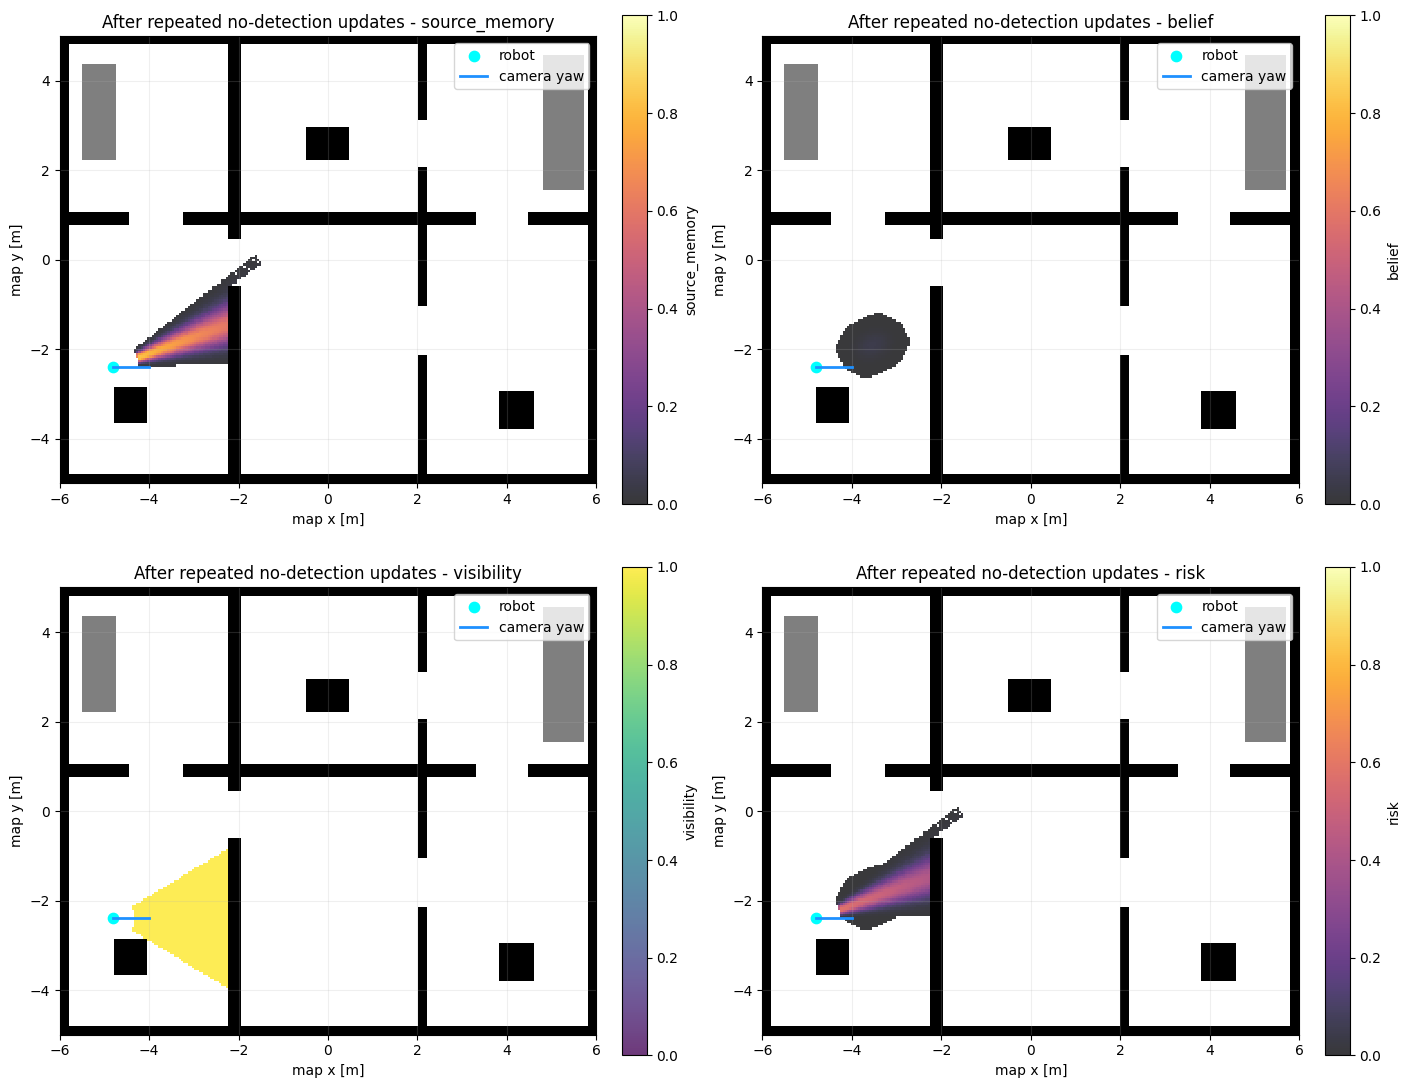

In [57]:
belief = np.zeros_like(occ_grid, dtype=np.float32)
source_memory = np.zeros_like(occ_grid, dtype=np.float32)

robot_x, robot_y, robot_yaw = -4.8, -2.4, math.radians(0.0)

ev = BearingEvidence(
    id=101,
    robot_x=robot_x,
    robot_y=robot_y,
    robot_yaw=robot_yaw,
    bearing_rad=math.radians(20.0),
    bearing_sigma_rad=math.radians(6.0),
    min_range_m=0.6,
    max_range_m=4.0,
    confidence=0.9,
)

history = []

# t0: detection
res = bayesian_person_belief_step(
    occ=occ_grid,
    belief_prev=belief,
    source_memory_prev=source_memory,
    robot_x=robot_x,
    robot_y=robot_y,
    robot_yaw=robot_yaw,
    detection_evidence=ev,
    clear_strength=0.12,
    p_detect_max=0.75,
    motion_sigma_m_per_step=0.15,
    belief_decay=0.995,
    allow_unknown=False,
)
belief = res["current_person_belief_map"]
source_memory = res["source_memory_map"]
history.append(("t0_detect", float(np.sum(belief)), float(np.sum(source_memory))))

# t1~t5: no detection
for k in range(1, 6):
    res = bayesian_person_belief_step(
        occ=occ_grid,
        belief_prev=belief,
        source_memory_prev=source_memory,
        robot_x=robot_x,
        robot_y=robot_y,
        robot_yaw=robot_yaw,
        detection_evidence=None,
        clear_strength=0.12,
        p_detect_max=0.75,
        motion_sigma_m_per_step=0.15,
        belief_decay=0.995,
        allow_unknown=False,
    )
    belief = res["current_person_belief_map"]
    source_memory = res["source_memory_map"]
    history.append((f"t{k}_no_det", float(np.sum(belief)), float(np.sum(source_memory))))

for tag, bsum, msum in history:
    print(f"{tag:>10s} | belief_sum={bsum:8.3f} | memory_sum={msum:8.3f}")

plot_bayesian_maps(
    occ=occ_grid,
    result=res,
    robot_x=robot_x,
    robot_y=robot_y,
    robot_yaw=robot_yaw,
    theta_map=None,
    title="After repeated no-detection updates",
    show_layers="all",
)

## 10. 시나리오 비교: detection 유/무 + 로봇 이동

이 셀은
- t0 detection
- t1 no detection (같은 위치)
- t2 no detection (로봇 이동 후 다른 시야)
를 연속 적용해 belief 재분포를 본다.

sum(t0)=293.416 | sum(t1)=78.729 | sum(t2)=34.082


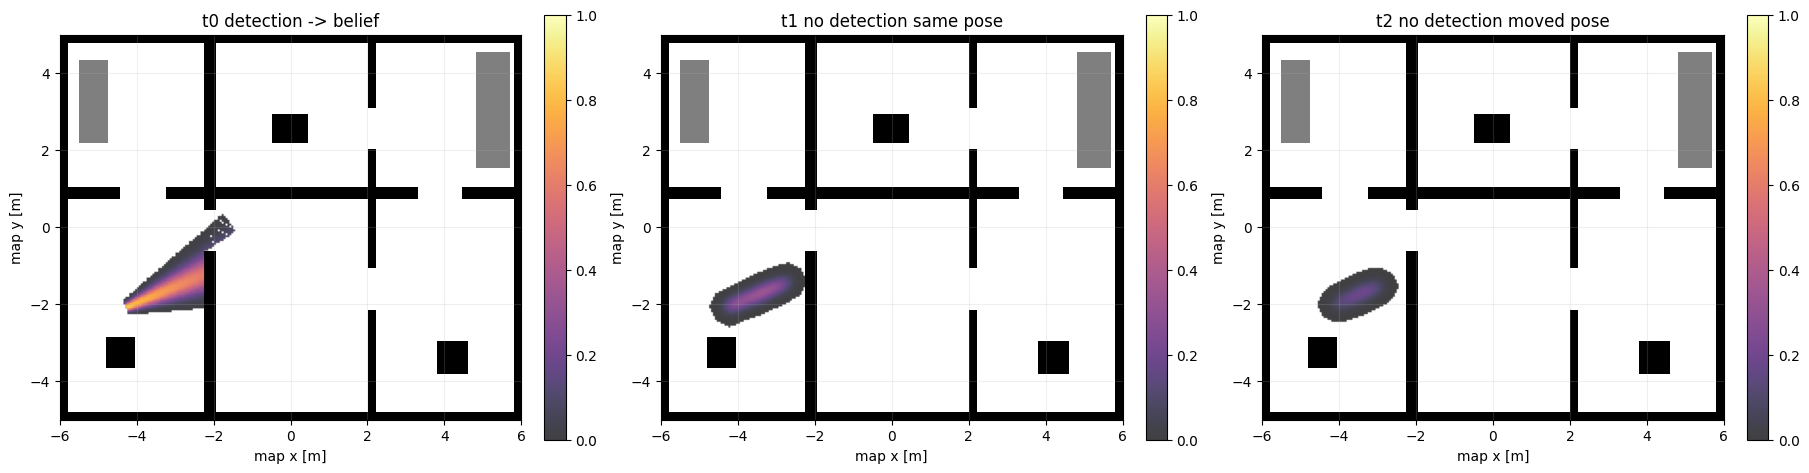

In [58]:
belief = np.zeros_like(occ_grid, dtype=np.float32)
source_memory = np.zeros_like(occ_grid, dtype=np.float32)

# t0 detection
pose0 = (-4.8, -2.3, math.radians(5.0))
ev0 = BearingEvidence(
    id=202,
    robot_x=pose0[0],
    robot_y=pose0[1],
    robot_yaw=pose0[2],
    bearing_rad=math.radians(18.0),
    bearing_sigma_rad=math.radians(6.0),
    min_range_m=0.6,
    max_range_m=4.0,
    confidence=0.9,
)

res0 = bayesian_person_belief_step(
    occ=occ_grid,
    belief_prev=belief,
    source_memory_prev=source_memory,
    robot_x=pose0[0],
    robot_y=pose0[1],
    robot_yaw=pose0[2],
    detection_evidence=ev0,
    allow_unknown=False,
    clear_strength=0.12,
    p_detect_max=0.75,
)
belief = res0["current_person_belief_map"]
source_memory = res0["source_memory_map"]

# t1 no detection same pose
res1 = bayesian_person_belief_step(
    occ=occ_grid,
    belief_prev=belief,
    source_memory_prev=source_memory,
    robot_x=pose0[0],
    robot_y=pose0[1],
    robot_yaw=pose0[2],
    detection_evidence=None,
    allow_unknown=False,
    clear_strength=0.12,
    p_detect_max=0.75,
)
belief = res1["current_person_belief_map"]
source_memory = res1["source_memory_map"]

# t2 no detection moved pose
pose2 = (-3.5, -1.0, math.radians(25.0))
res2 = bayesian_person_belief_step(
    occ=occ_grid,
    belief_prev=belief,
    source_memory_prev=source_memory,
    robot_x=pose2[0],
    robot_y=pose2[1],
    robot_yaw=pose2[2],
    detection_evidence=None,
    allow_unknown=False,
    clear_strength=0.12,
    p_detect_max=0.75,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for ax, data, title in [
    (axes[0], res0["current_person_belief_map"], "t0 detection -> belief"),
    (axes[1], res1["current_person_belief_map"], "t1 no detection same pose"),
    (axes[2], res2["current_person_belief_map"], "t2 no detection moved pose"),
]:
    plot_occupancy_map(occ_grid, ax=ax, title=title)
    masked = np.ma.masked_where(data <= 1e-4, data)
    im = ax.imshow(
        masked, origin="lower", extent=[grid.origin_x, grid.origin_x + grid.width_m, grid.origin_y, grid.origin_y + grid.height_m],
        cmap="inferno", vmin=0, vmax=1, alpha=0.75
    )
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

print(
    f"sum(t0)={float(np.sum(res0['current_person_belief_map'])):.3f} | "
    f"sum(t1)={float(np.sum(res1['current_person_belief_map'])):.3f} | "
    f"sum(t2)={float(np.sum(res2['current_person_belief_map'])):.3f}"
)
plt.show()

## 11. ROS2로 옮길 때 대응 관계 (Bayesian 버전)

이 노트북의 구성요소는 ROS2 패키지에서 다음처럼 대응된다.

| Notebook | ROS2 |
|---|---|
| `occ_grid` | `/map`의 `nav_msgs/OccupancyGrid.data` |
| `GridSpec` | `/map.info` |
| `BearingEvidence` | YOLO bbox + TF로 계산한 bearing evidence |
| `source_memory_map` | `/risk/source_memory_map` |
| `current_person_belief_map` | `/risk/current_person_belief_map` |
| `visibility_map` | `/risk/visibility_map` |
| `risk_map` | `/risk/risk_map` |
| `bayesian_person_belief_step()` | risk map rebuild timer callback |
| clear/confirm robot action | source memory clear API |

ROS2에서는 `source_memory_map`과 `current_person_belief_map`을 분리 저장하고,
매 사이클마다 prediction + visibility 기반 update를 수행하는 구조가 안정적이다.

## 12. 추천 파라미터 시작값 (Bayesian v1)

```python
# visibility
camera_hfov_deg = 62.0
vis_min_range_m = 0.5
vis_max_range_m = 5.0

# negative observation
clear_strength = 0.12
p_detect_max = 0.75

# positive observation
bearing_sigma_deg = 6.0
range_sigma_m = 1.0

# motion prediction
motion_sigma_m_per_step = 0.15
belief_decay = 0.995

# map constraints
allow_unknown = False

# risk fusion
source_memory_weight = 0.7
current_belief_weight = 1.0
```

목표가 “사람이 있을 가능성 확인”이면 `current_person_belief_map` 가중치를 높이고,
목표가 “과거 관측 위치 재확인”이면 `source_memory_map` 가중치를 높여서 `risk_map`을 구성한다.